<a href="https://colab.research.google.com/github/Viresh-tarapur/AIML_and_data_science_projects/blob/main/logistics2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing all neccessary libraries
import pandas as pd
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from pyspark.sql.functions import year, month, avg, date_format
from pyspark.sql.functions import year, date_format, sum, count, when, col
from pyspark.sql.functions import month, year, date_format



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/archive.zip'  # change path as needed
extract_to = '/content/drive/MyDrive/'   # output folder

# Create folder if not exists
os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzip Completed!")


Unzip Completed!


In [ ]:
!pip install pyspark


In [ ]:
# Install Spark
!pip install pyspark

# Start SparkSession
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("IoT Logistics Analysis").getOrCreate()

# Import libraries
import pandas as pd
from pyspark.sql.functions import col, year, month, date_format, sum, count, when
import matplotlib.pyplot as plt

# Load CSV from Drive
file_path = "/content/drive/MyDrive/smart_logistics_dataset.csv"
df_pd = pd.read_csv(file_path)

# Convert to Spark DataFrame
df = spark.createDataFrame(df_pd)

# Show dataset
df.show(5)


+-------------------+--------+--------+---------+---------------+---------------+-----------+--------+--------------+------------+-----------------------+-----------------------+----------------------+-----------------+---------------+---------------+
|          Timestamp|Asset_ID|Latitude|Longitude|Inventory_Level|Shipment_Status|Temperature|Humidity|Traffic_Status|Waiting_Time|User_Transaction_Amount|User_Purchase_Frequency|Logistics_Delay_Reason|Asset_Utilization|Demand_Forecast|Logistics_Delay|
+-------------------+--------+--------+---------+---------------+---------------+-----------+--------+--------------+------------+-----------------------+-----------------------+----------------------+-----------------+---------------+---------------+
|2024-03-20 00:11:14| Truck_7|-65.7383|  11.2497|            390|        Delayed|       27.0|    67.8|        Detour|          38|                    320|                      4|                   NaN|             60.1|            285|         

In [ ]:
# Generating summary statistics of the dataset
summary_df = df.describe()
display(summary_df)


DataFrame[summary: string, Timestamp: string, Asset_ID: string, Latitude: string, Longitude: string, Inventory_Level: string, Shipment_Status: string, Temperature: string, Humidity: string, Traffic_Status: string, Waiting_Time: string, User_Transaction_Amount: string, User_Purchase_Frequency: string, Logistics_Delay_Reason: string, Asset_Utilization: string, Demand_Forecast: string, Logistics_Delay: string]

In [ ]:
# Changing data types of the specified columns
df = df.withColumn("Timestamp", col("Timestamp").cast("date")) \
       .withColumn("Waiting_Time", col("Waiting_Time").cast("int")) \
       .withColumn("User_Transaction_Amount", col("User_Transaction_Amount").cast("int"))

# Displaying the updated DataFrame
display(df.limit(10))

DataFrame[Timestamp: date, Asset_ID: string, Latitude: double, Longitude: double, Inventory_Level: bigint, Shipment_Status: string, Temperature: double, Humidity: double, Traffic_Status: string, Waiting_Time: int, User_Transaction_Amount: int, User_Purchase_Frequency: bigint, Logistics_Delay_Reason: string, Asset_Utilization: double, Demand_Forecast: bigint, Logistics_Delay: bigint]

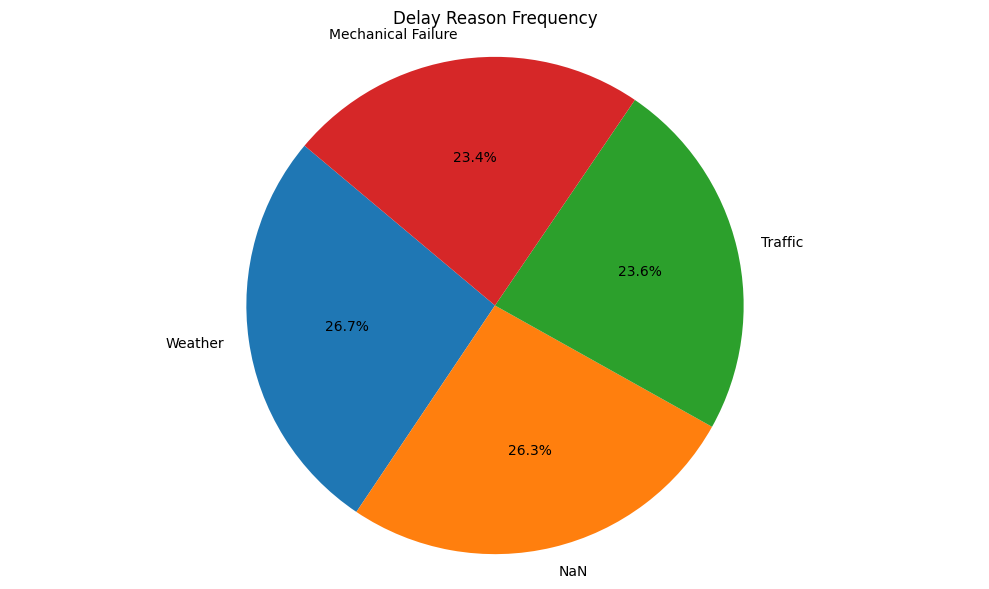

In [ ]:
# Grouping by delay reason and counting occurrences
delay_frequency_df = df.groupBy("Logistics_Delay_Reason").count()

# Collecting data for plotting
delay_data = delay_frequency_df.select("Logistics_Delay_Reason", "count").orderBy("count", ascending=False).toPandas()

# Displaying the pie chart
plt.figure(figsize=(10, 6))
plt.pie(delay_data['count'], labels=delay_data['Logistics_Delay_Reason'], autopct='%1.1f%%', startangle=140)
plt.title('Delay Reason Frequency')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()


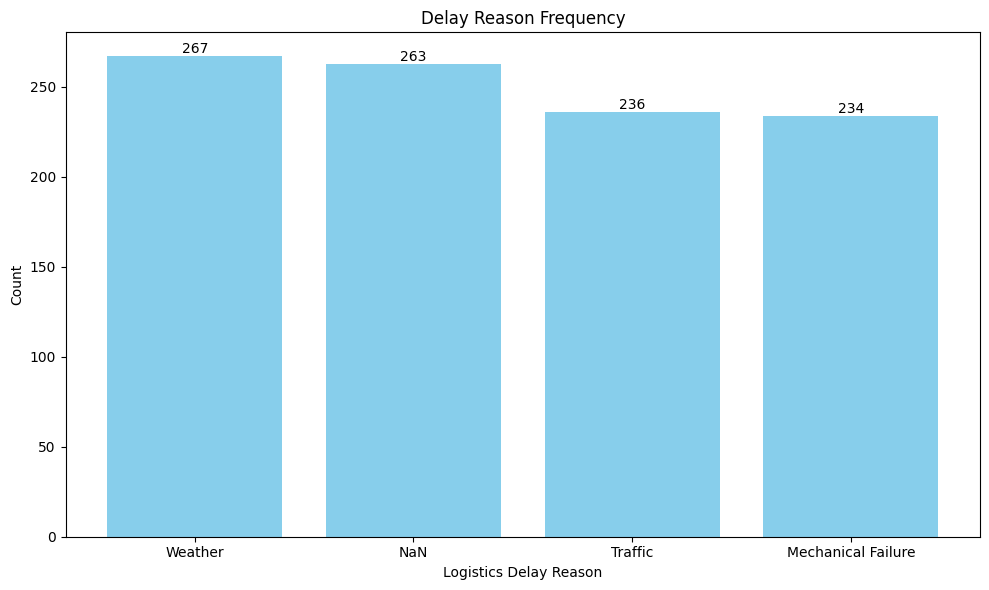

In [ ]:
# Grouping by delay reason and counting occurrences
delay_frequency_df = df.groupBy("Logistics_Delay_Reason").count()

# Collecting data for plotting
delay_data = delay_frequency_df.select("Logistics_Delay_Reason", "count").orderBy("count", ascending=False).toPandas()

# Displaying the bar chart with labels and colors
plt.figure(figsize=(10, 6))
bars = plt.bar(delay_data['Logistics_Delay_Reason'], delay_data['count'], color='skyblue')
plt.title('Delay Reason Frequency')
plt.xlabel('Logistics Delay Reason')
plt.ylabel('Count')
plt.xticks(rotation=360)

# Adding data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()


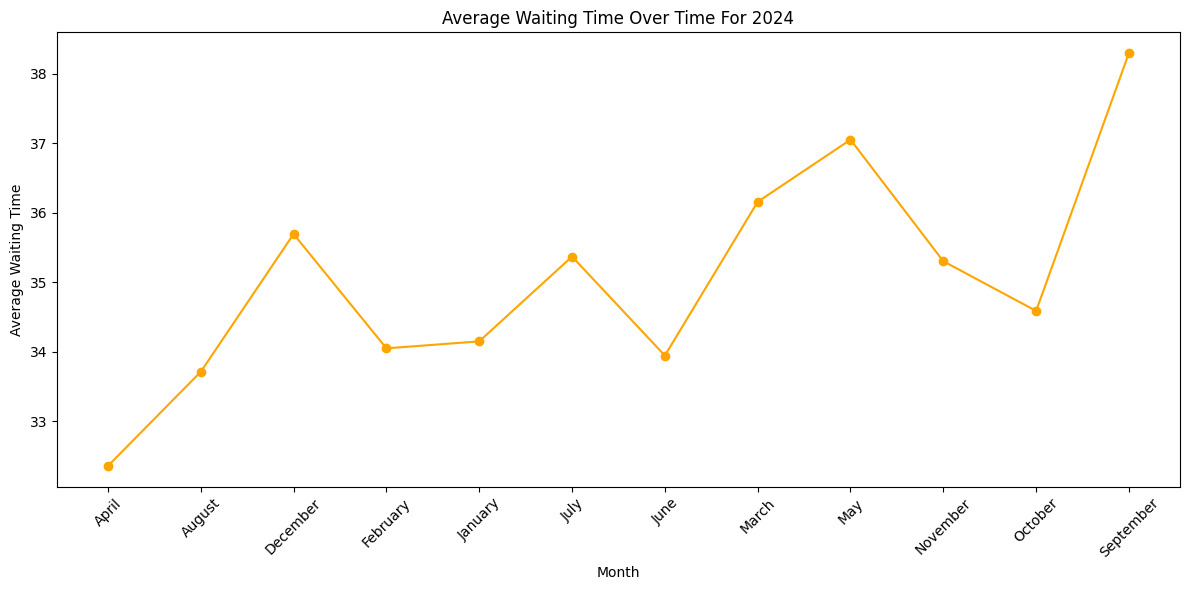

In [ ]:
plt.show()
# Calculating average waiting time per month
average_waiting_time_df = df.withColumn("Year", year("Timestamp")) \
                             .withColumn("Month", date_format("Timestamp", "MMMM")) \
                             .groupBy("Year", "Month") \
                             .agg(avg("Waiting_Time").alias("Average_Waiting_Time")) \
                             .orderBy("Year", "Month")

# Collecting data for plotting
average_waiting_time_data = average_waiting_time_df.select("Year", "Month", "Average_Waiting_Time").toPandas()

# Displaying the line chart
plt.figure(figsize=(12, 6))
plt.plot(average_waiting_time_data['Month'],
         average_waiting_time_data['Average_Waiting_Time'], marker='o', color='orange')
plt.title('Average Waiting Time Over Time For 2024')
plt.xlabel('Month')
plt.ylabel('Average Waiting Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


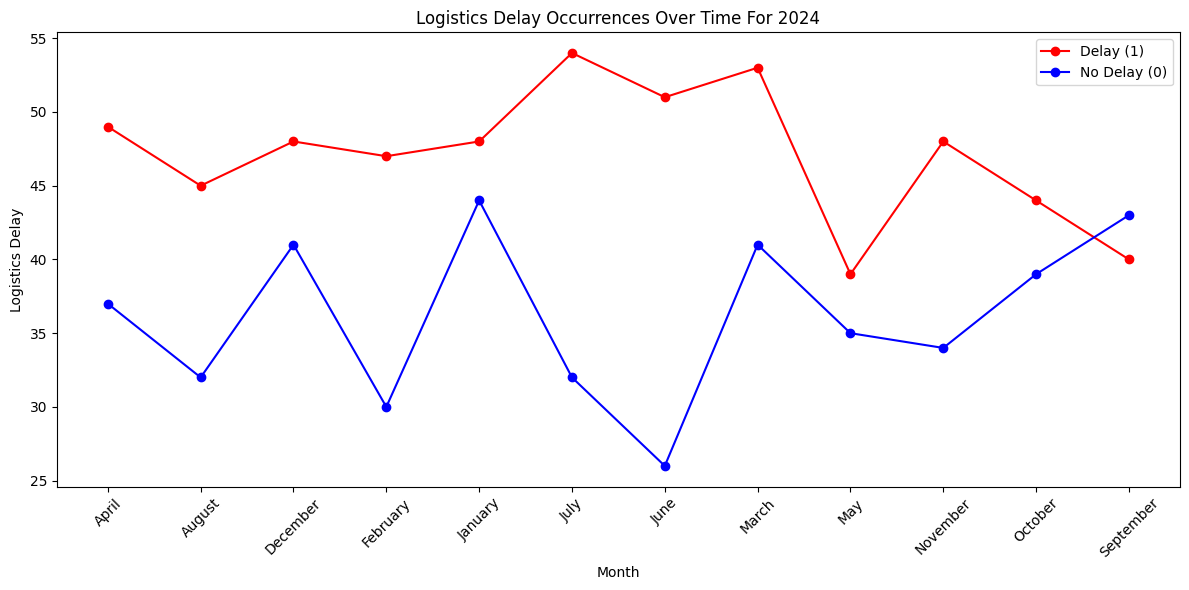

In [ ]:
# Calculating logistics delay occurrences per month
logistics_delay_df = df.withColumn("Year", year("Timestamp")) \
                       .withColumn("Month", date_format("Timestamp", "MMMM")) \
                       .groupBy("Year", "Month") \
                       .agg(sum("Logistics_Delay").alias("Logistics_Delay_Count"),
                            count(when(col("Logistics_Delay") == 0, 1)).alias("No_Delay_Count")) \
                       .orderBy("Year", "Month")

# Collecting data for plotting
logistics_delay_data = logistics_delay_df.select("Year", "Month", "Logistics_Delay_Count", "No_Delay_Count").toPandas()

# Displaying the line chart
plt.figure(figsize=(12, 6))
plt.plot(logistics_delay_data['Month'],
         logistics_delay_data['Logistics_Delay_Count'], marker='o', color='red', label='Delay (1)')
plt.plot(logistics_delay_data['Month'],
         logistics_delay_data['No_Delay_Count'], marker='o', color='blue', label='No Delay (0)')
plt.title('Logistics Delay Occurrences Over Time For 2024')
plt.xlabel('Month')
plt.ylabel('Logistics Delay')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

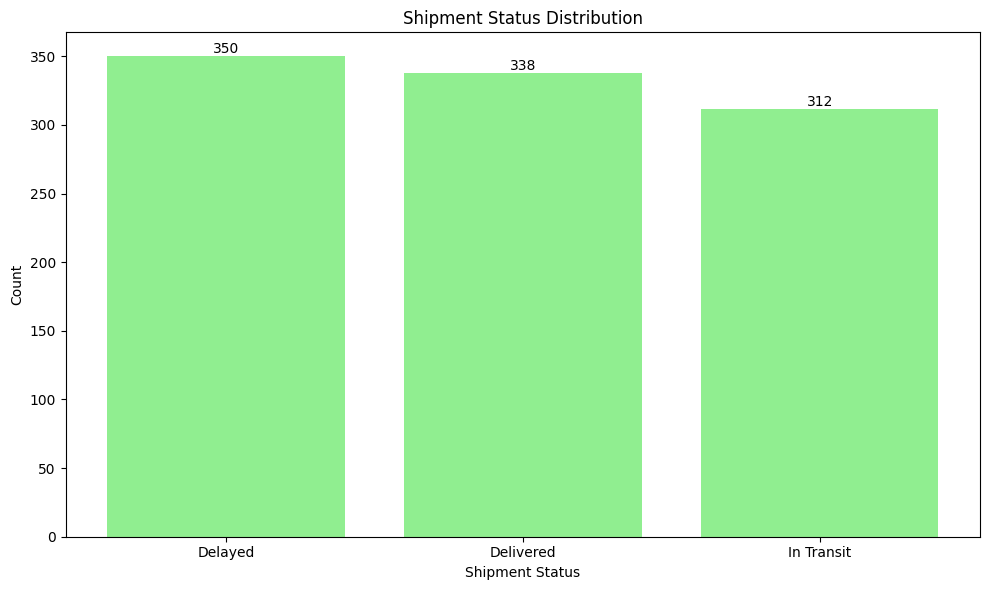

In [ ]:
# Grouping by shipment status and counting occurrences
shipment_status_df = df.groupBy("Shipment_Status").count()

# Collecting data for plotting
shipment_status_data = shipment_status_df.select("Shipment_Status", "count").orderBy("count", ascending=False).toPandas()

# Displaying the bar chart with labels and colors
plt.figure(figsize=(10, 6))
bars = plt.bar(shipment_status_data['Shipment_Status'], shipment_status_data['count'], color='lightgreen')
plt.title('Shipment Status Distribution')
plt.xlabel('Shipment Status')
plt.ylabel('Count')
plt.xticks(rotation=360)

# Adding data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')

plt.tight_layout()
plt.show()

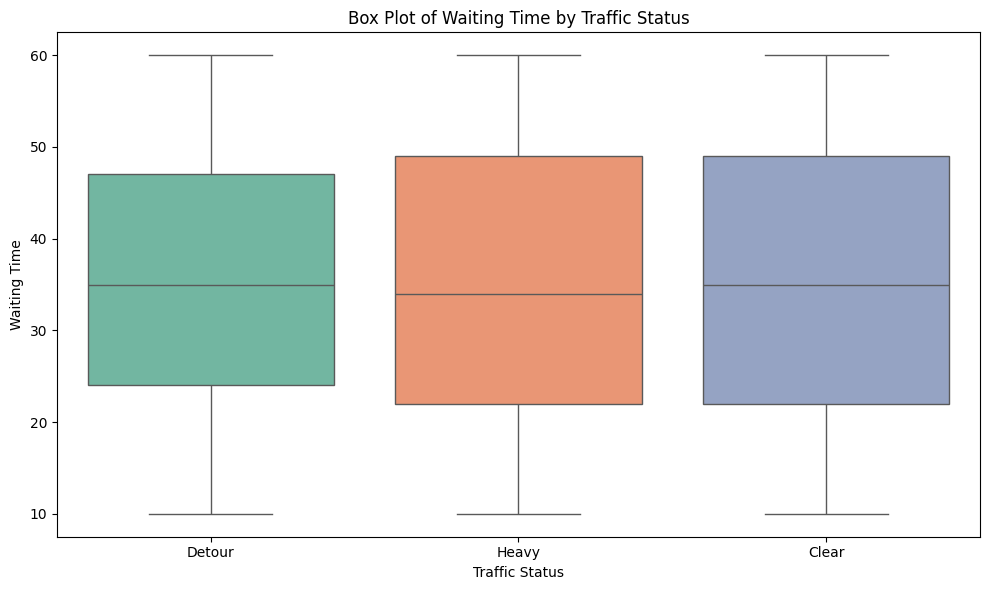

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Spark DataFrame for the boxplot
waiting_time_boxplot_df = df.select("Traffic_Status", "Waiting_Time")

# 2. Convert Spark DataFrame to Pandas for seaborn plotting
waiting_time_boxplot_data = waiting_time_boxplot_df.toPandas()

# 3. Draw boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Traffic_Status',
    y='Waiting_Time',
    data=waiting_time_boxplot_data,
    hue='Traffic_Status',
    palette='Set2',
    legend=False
)

plt.title('Box Plot of Waiting Time by Traffic Status')
plt.xlabel('Traffic Status')
plt.ylabel('Waiting Time')
plt.tight_layout()
plt.show()


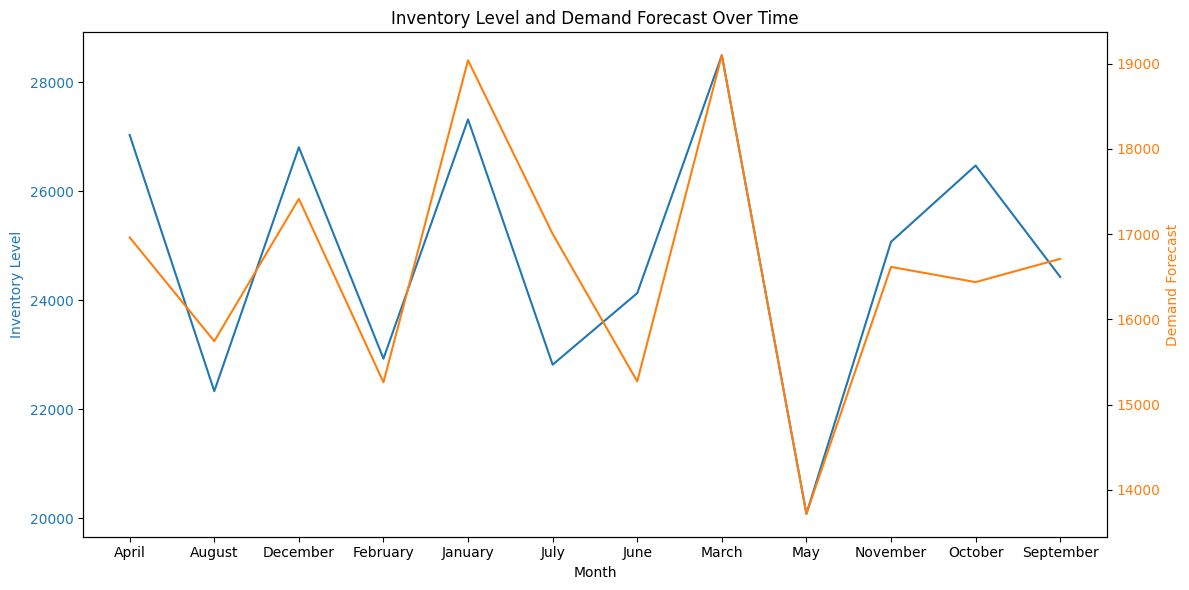

In [ ]:
# Extracting Month and Year from Timestamp
df = df.withColumn("Month", month("Timestamp")).withColumn("Year", year("Timestamp")) \
       .withColumn("Month_Name", date_format("Timestamp", "MMMM"))

# Preparing data for dual axis line chart
time_series_data = df.select("Timestamp", "Inventory_Level", "Demand_Forecast", "Month_Name", "Year") \
    .groupBy("Month_Name", "Year") \
    .agg({"Inventory_Level": "sum", "Demand_Forecast": "sum"}) \
    .orderBy("Year", "Month_Name") \
    .toPandas()

# Creating the dual axis line chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Inventory Level
ax1.set_xlabel('Month')
ax1.set_ylabel('Inventory Level', color='tab:blue')
ax1.plot(time_series_data['Month_Name'],
         time_series_data['sum(Inventory_Level)'], color='tab:blue', label='Inventory Level')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Creating a second y-axis for Demand Forecast
ax2 = ax1.twinx()
ax2.set_ylabel('Demand Forecast', color='tab:orange')
ax2.plot(time_series_data['Month_Name'],
         time_series_data['sum(Demand_Forecast)'], color='tab:orange', label='Demand Forecast')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Adding title and layout adjustments
plt.title('Inventory Level and Demand Forecast Over Time')
fig.tight_layout()
plt.show()

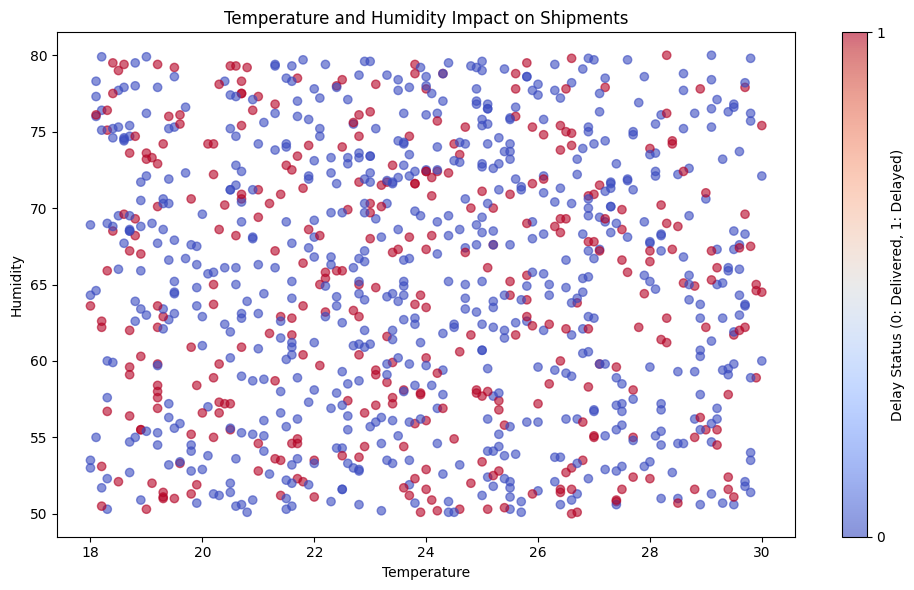

In [ ]:
# Preparing data for scatter plot
scatter_data = df.select("Temperature", "Humidity", "Shipment_Status").toPandas()

# Creating the scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(scatter_data['Temperature'], scatter_data['Humidity'],
                      c=scatter_data['Shipment_Status'].apply(lambda x: 1 if x == 'Delayed' else 0),
                      cmap='coolwarm', alpha=0.6)

# Adding color bar
plt.colorbar(scatter, ticks=[0, 1], label='Delay Status (0: Delivered, 1: Delayed)')

# Adding labels and title
plt.title('Temperature and Humidity Impact on Shipments')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.tight_layout()
plt.show()

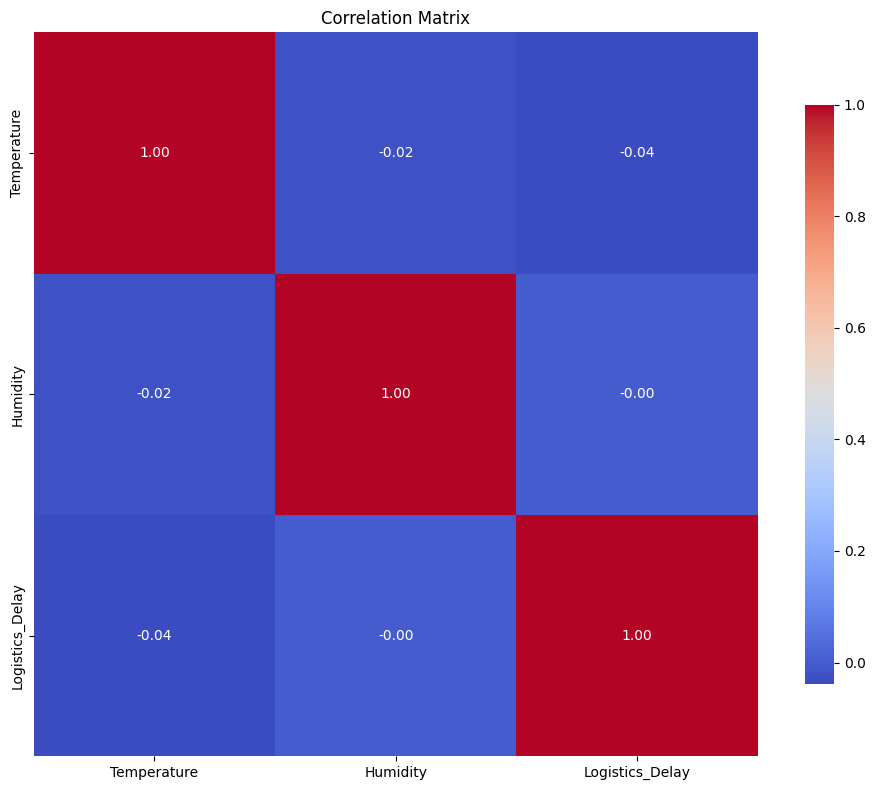

In [ ]:
# Preparing data for correlation matrix
correlation_data = df.select("Temperature", "Humidity", "Logistics_Delay").toPandas()

# Calculating the correlation matrix
correlation_matrix = correlation_data.corr()

# Creating the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.tight_layout()

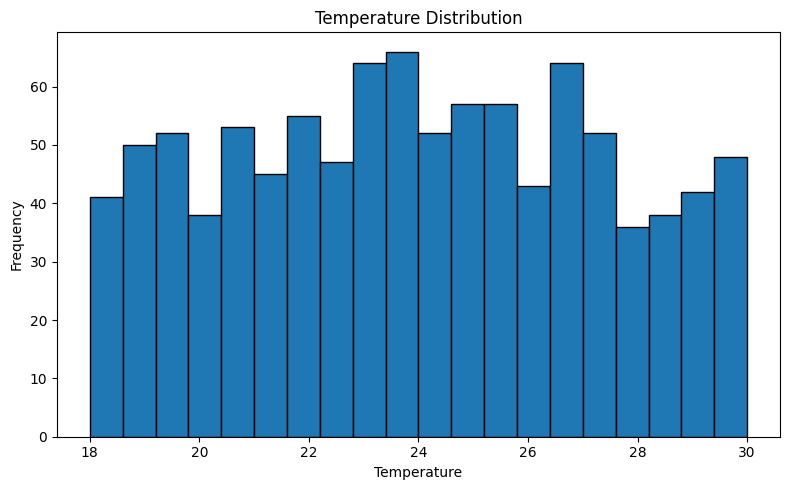

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_pd['Temperature'], bins=20, edgecolor='black')
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


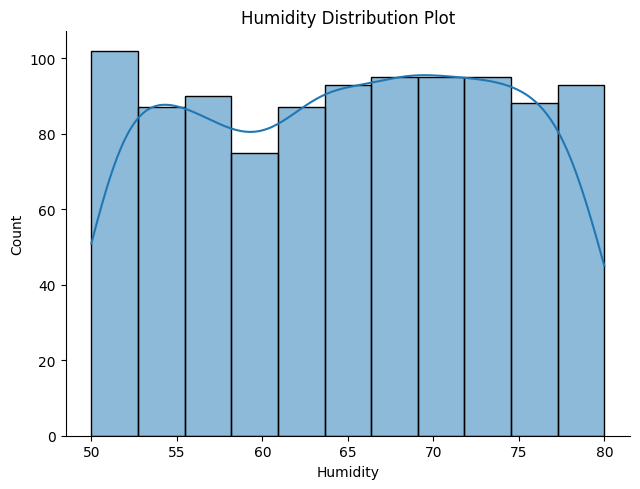

In [ ]:
sns.displot(df_pd['Humidity'], kde=True, height=5, aspect=1.3)
plt.title("Humidity Distribution Plot")
plt.xlabel("Humidity")
plt.tight_layout()
plt.show()


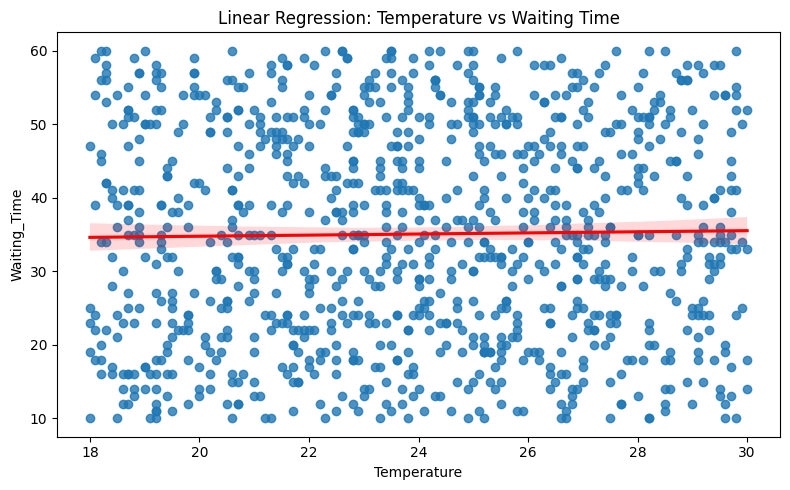

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.regplot(x='Temperature', y='Waiting_Time', data=df_pd, line_kws={"color":"red"})
plt.title("Linear Regression: Temperature vs Waiting Time")
plt.tight_layout()
plt.show()
